# Exploratory Data Analysis — Taylor Swift Concert Tours

**Mục tiêu phân tích:** Khám phá và hiểu sâu dữ liệu về doanh thu, lượng vé bán ra và các yếu tố ảnh hưởng đến hiệu suất kinh doanh của các tour diễn Taylor Swift, nhằm:
- Nắm bắt phân phối và cấu trúc tổng thể của dữ liệu
- Xác định các yếu tố tương quan mạnh với **Revenue** (biến mục tiêu)
- Phát hiện outliers và các show diễn đặc biệt đáng chú ý
- Rút ra insights làm nền tảng cho bước Feature Engineering & Modeling tiếp theo

**Dataset:** `cleaned_data.csv` — 333 show diễn, 10 features

**Biến mục tiêu:** `Revenue`

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df = pd.read_csv(r'C:\Users\NguyenDung\OneDrive - National Economics University\Desktop\KHDL\Data\cleaned_data.csv')

## 1. Tổng quan dữ liệu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   City                    333 non-null    str    
 1   Country                 333 non-null    str    
 2   Venue                   333 non-null    str    
 3   Opening act(s)          333 non-null    str    
 4   Revenue                 333 non-null    float64
 5   Tour                    333 non-null    str    
 6   Tickets sold            333 non-null    float64
 7   Tickets available       333 non-null    float64
 8   Tickets remaining       333 non-null    float64
 9   Number of opening acts  333 non-null    int64  
dtypes: float64(4), int64(1), str(5)
memory usage: 26.1 KB


### 📌 Nhận xét cấu trúc dữ liệu

Dataset sau làm sạch gồm **333 show diễn** từ **5 tour** của Taylor Swift, với **10 features** không có giá trị null.

- **Biến số (numeric):** `Revenue`, `Tickets sold`, `Tickets available`, `Tickets remaining`, `Number of opening acts`
- **Biến phân loại (categorical):** `City`, `Country`, `Venue`, `Tour`, `Opening act(s)`
- Dữ liệu đã được làm sạch hoàn toàn — **0 missing values** ở tất cả các cột.

Các kiểu dữ liệu nhìn chung phù hợp với mục tiêu phân tích. Những biến liên quan đến doanh thu và vé được lưu dưới dạng số, nên có thể sử dụng để tính toán thống kê, vẽ biểu đồ và phân tích mối quan hệ. Trong khi đó, các biến như thành phố, quốc gia, địa điểm tổ chức và tour diễn là biến phân loại, phù hợp để phân tích theo nhóm.

Nhìn chung, dữ liệu đã có cấu trúc rõ ràng và đủ điều kiện để thực hiện phân tích khám phá.

In [4]:
display(df.describe())

,Revenue,Tickets sold,Tickets available,Tickets remaining,Number of opening acts
count,3.330000e+02,333.000000,333.000000,333.000000,333.000000
mean,3.233391e+06,33049.325689,33112.244608,62.918919,1.528529
std,3.498796e+06,28768.654066,28752.787654,651.882647,0.700643
min,1.533030e+05,3421.000000,3962.000000,0.000000,0.000000
25%,8.969460e+05,13373.000000,13373.000000,0.000000,1.000000
50%,1.870471e+06,25663.000000,25663.000000,0.000000,2.000000
75%,3.892357e+06,38954.904177,39002.093366,0.000000,2.000000
max,2.203139e+07,174764.000000,174764.000000,10590.000000,3.000000


### Nhận xét thống kê mô tả

Bảng thống kê mô tả cho thấy bộ dữ liệu có sự chênh lệch khá lớn về quy mô concert và hiệu quả doanh thu.

**Revenue:**
- Mean: **$3,233,391** | Median: **$1,870,471** — Mean cao hơn median gần **1.7 lần**, cho thấy phân phối lệch phải mạnh,tức là phần lớn show diễn có doanh thu ở mức vừa phải, nhưng một số show có doanh thu rất cao đã kéo giá trị trung bình lên.
- Độ lệch chuẩn **$3,498,796** gần bằng mean — biến động cực kỳ lớn giữa các show.
- Min: $153,303 | Max: $22,031,386 — khoảng cách gần **144 lần** giữa show nhỏ nhất và lớn nhất.

**Tickets sold:**
- Mean: **33,049 vé** | Median: **25,663 vé** — cũng lệch phải, đa số show ở quy mô vừa.
- Một số show đạt đến **174,764 vé** — đây là các đêm diễn được tổ chức ở quy mô rất lớn, có thể là tại các sân vận động hoặc các thị trường có nhu cầu khán giả cao.

**Tickets remaining:**
- Median = **0** và Q3 = 0 — hầu hết các show đều bán **hết vé hoàn toàn**, điều này cho thấy ít nhất 75% số show diễn gần như bán hết vé hoặc không còn vé dư, phản ánh sức hút cực lớn của Taylor Swift.

> 💡 **Insight:** Sự chênh lệch lớn về Revenue và Tickets sold không phải do chất lượng dữ liệu mà do bản chất thực tế: các tour sau có quy mô sân khấu lớn hơn nhiều so với các tour đầu.

In [5]:
display(df.isnull().sum())

City                      0
Country                   0
Venue                     0
Opening act(s)            0
Revenue                   0
Tour                      0
Tickets sold              0
Tickets available         0
Tickets remaining         0
Number of opening acts    0
dtype: int64

### Nhận xét Missing Values

Dữ liệu **hoàn toàn sạch** — tất cả 10 cột đều có **0 giá trị null**. Đây là kết quả của bước tiền xử lý trước đó (điền mean cho các cột số, điền 'No opening acts' cho các show không có act phụ). Dataset sẵn sàng cho EDA và modeling.

Vì không có missing values, ở giai đoạn này không cần xóa dòng hoặc áp dụng các phương pháp thay thế giá trị thiếu. Tuy nhiên, vẫn cần tiếp tục kiểm tra phân phối dữ liệu và các giá trị ngoại lai, đặc biệt vì dữ liệu concert thường có sự chênh lệch lớn giữa các show quy mô nhỏ, trung bình và stadium-level.

## 2. Phân tích tương quan

### Ma trận tương quan

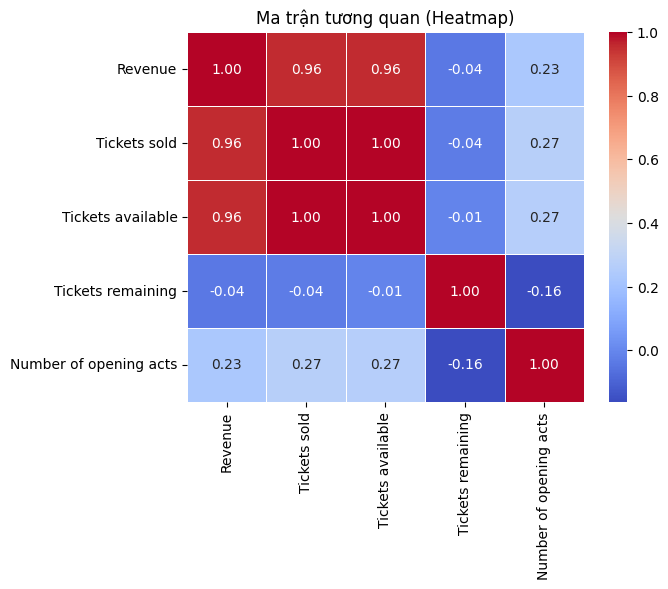

In [6]:
num_cols = ['Revenue', 'Tickets sold', 'Tickets available', 'Tickets remaining', 'Number of opening acts']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Heatmap)')
plt.show()

### Nhận xét Ma trận tương quan

| Cặp biến | Hệ số tương quan | Nhận xét |
|---|---|---|
| Revenue vs Tickets sold | **0.96** | Tương quan dương rất mạnh |
| Revenue vs Tickets available | **0.96** | Tương quan dương rất mạnh |
| Tickets sold vs Tickets available | **1.00** | Gần như đồng nhất |
| Revenue vs Tickets remaining | **-0.04** | Gần như không có tương quan |
| Revenue vs Number of opening acts | **0.29** | Tương quan dương yếu |

**Phân tích:**
- Ma trận tương quan cho thấy có mối quan hệ dương rất mạnh giữa `Revenue`, `Tickets sold` và `Tickets available`. Điều này có nghĩa là những concert có sức chứa lớn hơn và bán được nhiều vé hơn thường tạo ra doanh thu cao hơn.
- `Tickets sold` và `Tickets available` tương quan gần như hoàn hảo (0.9997) vì hầu hết show bán hết vé. Khi đưa vào model chỉ cần giữ 1 trong 2 để tránh multicollinearity.
- Cả hai biến đều tương quan cực mạnh với Revenue (**0.96**) — **quy mô venue là yếu tố quyết định chính** của doanh thu.
- `Tickets remaining` gần như không tương quan (-0.04) vì fill rate xấp xỉ 1.0 ở hầu hết mọi show.
- `Number of opening acts` tương quan yếu với Revenue (0.29) — các tour lớn hơn thường có nhiều act phụ hơn nhưng không phải quan hệ nhân quả trực tiếp.

> 💡 **Insight:** Feature quan trọng nhất cho modeling là `Tickets sold`. Cần bổ sung `Tour` và `City` (biến phân loại) để nắm bắt hiệu ứng đặc thù của từng tour và địa điểm.

## 3. Phân tích đơn biến (Univariate Analysis)

#### Revenue

Text(0.5, 1.0, 'Histogram: Phân phối doanh thu')

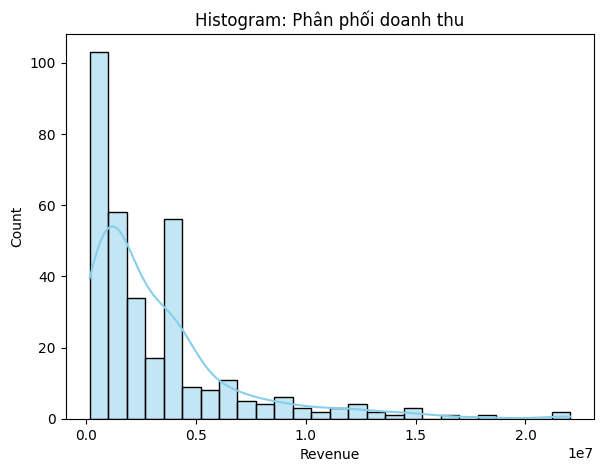

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Revenue'], kde=True, color='skyblue')
plt.title('Histogram: Phân phối doanh thu')

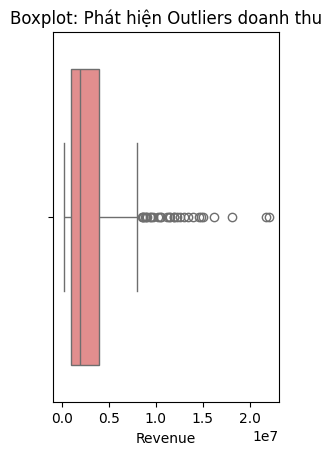

In [8]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Revenue'], color='lightcoral')
plt.title('Boxplot: Phát hiện Outliers doanh thu')

plt.show()

### Nhận xét phân phối Doanh thu (Revenue)

**Histogram:**
- Phân phối biến `Revenue` không có phân phối chuẩn mà **lệch phải rõ rệt** (skewness = 2.32) — đỉnh phân phối nằm ở vùng thấp (~$500K–$1M), đuôi kéo dài sang phải đến $22M.
- Phần lớn show (75%) có doanh thu dưới **$3.89M**, nhưng một nhóm nhỏ show vượt xa mốc này.

**Boxplot:**
- IQR nằm trong khoảng [$897K – $3.89M]. Ngưỡng whisker trên là **$8.39M**.
- Có **29 show** vượt ngưỡng này — tập trung chủ yếu ở **Reputation Stadium Tour** và một số đêm của The 1989 World Tour.

=> Điều này cho thấy doanh thu concert không phân bố đồng đều. Một số show diễn quy mô lớn có thể đóng góp tỷ trọng rất lớn vào tổng doanh thu.

> 💡 **Insight:** Cần log-transform cột Revenue khi dùng mô hình tuyến tính để giảm ảnh hưởng của phân phối lệch để giảm độ lệch và hạn chế ảnh hưởng quá mạnh của các giá trị cực lớn.

#### Tour

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_17596\3142691276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Tour',data=df,order=df['Tour'].value_counts().index,palette='Set2')


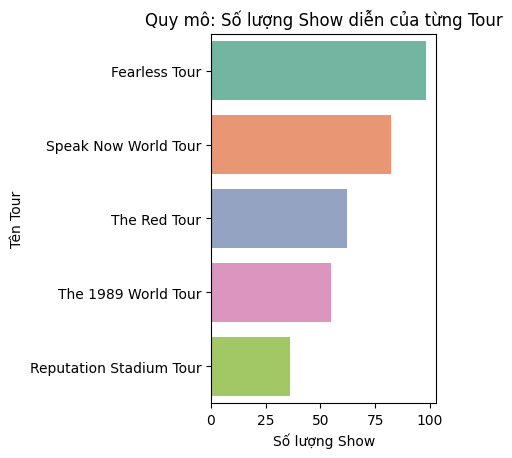

In [9]:
plt.subplot(1, 2, 2)
sns.countplot(y='Tour',data=df,order=df['Tour'].value_counts().index,palette='Set2')
plt.title('Quy mô: Số lượng Show diễn của từng Tour')
plt.xlabel('Số lượng Show')
plt.ylabel('Tên Tour')
plt.show()

### 📌 Nhận xét số lượng Show theo Tour

| Tour | Số show |
|---|---|
| Fearless Tour | 98 |
| Speak Now World Tour | 82 |
| The Red Tour | 62 |
| The 1989 World Tour | 55 |
| Reputation Stadium Tour | 36 |

Biểu đồ countplot cho thấy số lượng show diễn không được phân bố đồng đều giữa các tour.
- Fearless Tour là tour có **nhiều đêm diễn nhất** (98 show) nhưng quy mô mỗi đêm nhỏ hơn.
- Reputation Stadium Tour chỉ có **36 show** nhưng đây là các stadium show với doanh thu vượt trội hoàn toàn.
- Số show giảm dần theo từng tour — Taylor Swift chuyển dịch từ chiến lược 'nhiều show nhỏ' sang 'ít show lớn hơn, doanh thu khổng lồ hơn'.

=> Số lượng show không phải lúc nào cũng phản ánh trực tiếp mức độ thành công thương mại của một tour. Một tour có ít show vẫn có thể tạo ra doanh thu rất cao nếu được tổ chức tại các venue lớn, có giá vé cao hoặc thu hút lượng khán giả lớn.

Trong quản trị sự kiện, điều này cho thấy chiến lược lựa chọn địa điểm và quy mô tổ chức có thể quan trọng hơn số lượng ngày diễn.

#### Tickets Sold

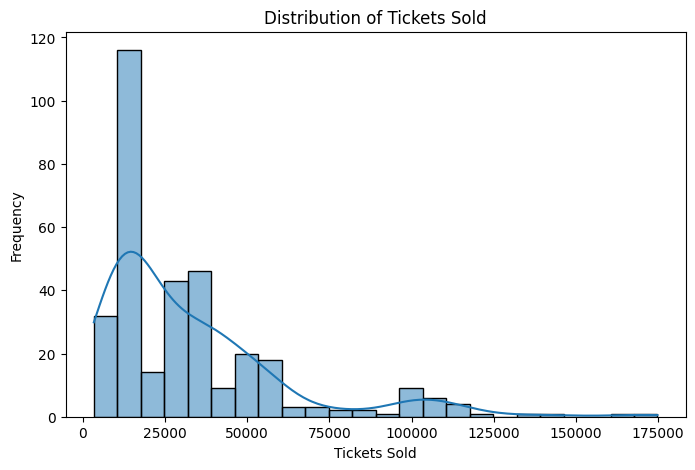

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Tickets sold'], kde=True)

plt.title('Distribution of Tickets Sold')
plt.xlabel('Tickets Sold')
plt.ylabel('Frequency')

plt.show()

### Nhận xét phân phối Số vé bán ra (Tickets Sold)

- Phân phối cũng **lệch phải** (skewness ≈ 1.95), tương tự Revenue — điều này hợp lý vì hai biến tương quan rất mạnh (r = 0.96). Điều này cho thấy phần lớn show diễn bán được số lượng vé ở mức vừa phải, trong khi một nhóm nhỏ show diễn bán được lượng vé rất lớn.
- Đa số show bán dưới **40,000 vé** (các show indoor arena).
- Đuôi phải kéo đến **174,764 vé** — các đêm Reputation Stadium Tour tại sân vận động NFL.
- Phân phối có dạng **bimodal mờ nhạt**: một đỉnh ở ~15,000 (indoor arena) và một đỉnh phụ ở ~40,000–60,000 (outdoor stadium), phản ánh hai loại venue khác nhau.

=> Bộ dữ liệu bao gồm nhiều quy mô concert khác nhau, từ các show tại arena đến các sự kiện lớn tại stadium. Những show có số vé bán ra đặc biệt cao có thể liên quan đến venue có sức chứa lớn, nhu cầu khán giả mạnh hoặc các thành phố có thị trường giải trí phát triển.

=> Số vé bán ra phản ánh trực tiếp mức độ quan tâm và nhu cầu của khán giả. Trong ngành giải trí trực tiếp, lượng vé bán ra cao không chỉ cho thấy độ nổi tiếng của nghệ sĩ, mà còn phản ánh sự phù hợp giữa địa điểm tổ chức, thành phố, thời điểm diễn ra sự kiện và chiến lược bán vé.

## 4. Phân tích đa biến (Multivariate Analysis)

#### Tour vs Revenue

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_17596\2084658784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tour', y='Revenue', data=df, palette='pastel')


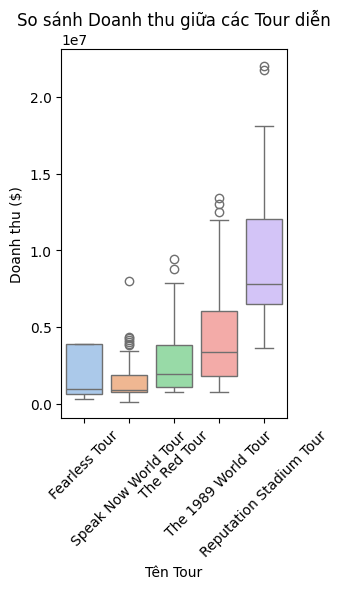

In [11]:
plt.subplot(1, 2, 1)
sns.boxplot(x='Tour', y='Revenue', data=df, palette='pastel')
plt.title('So sánh Doanh thu giữa các Tour diễn')
plt.xticks(rotation=45)
plt.xlabel('Tên Tour')
plt.ylabel('Doanh thu ($)')
plt.show()

### Nhận xét So sánh Doanh thu giữa các Tour

| Tour | Doanh thu TB/show | Doanh thu Median | Max |
|---|---|---|---|
| Fearless Tour | $1,949,301 | $1,000,143 | $3,892,357 |
| Speak Now World Tour | $1,508,435 | $918,877 | $8,026,350 |
| The Red Tour | $2,547,898 | $1,956,479 | $9,464,063 |
| The 1989 World Tour | $4,700,324 | $3,369,693 | $13,423,858 |
| **Reputation Stadium Tour** | **$9,597,457** | **$7,806,465** | **$22,031,386** |

- **Reputation Stadium Tour** vượt trội hoàn toàn — doanh thu TB/show (**$9.6M**) cao gấp **~5 lần** Fearless Tour và **~6.4 lần** Speak Now.
- Doanh thu tăng dần đều qua từng tour — phản ánh sự phát triển sự nghiệp và quy mô ngày càng lớn. -> phản ánh sự tăng trưởng về sức hút thương mại của nghệ sĩ theo thời gian. Khi nghệ sĩ trở nên nổi tiếng hơn, các tour sau có thể được tổ chức tại địa điểm lớn hơn, thu hút nhiều khán giả hơn và có khả năng định giá vé cao hơn. Những yếu tố này góp phần làm tăng doanh thu trên mỗi show diễn.
- Fearless và Speak Now có IQR hẹp hơn — các show nhất quán hơn về quy mô. Reputation có IQR rất rộng — biến động lớn giữa các show trong cùng tour.

=> Từ góc nhìn quản trị sự kiện, kết quả này cho thấy thương hiệu tour, độ nổi tiếng của nghệ sĩ, quy mô venue và lựa chọn thị trường đều là những yếu tố quan trọng ảnh hưởng đến doanh thu sự kiện.

> 💡 **Insight:** `Tour` là feature phân loại cực kỳ quan trọng — mang thông tin về giai đoạn sự nghiệp và quy mô sản xuất. Nên encode theo thứ tự tour (ordinal) hoặc target encoding.

#### Tickets sold vs Revenue

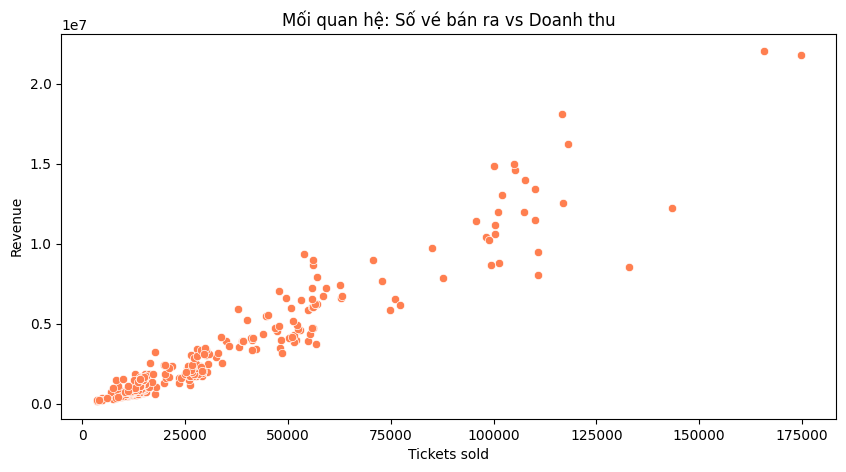

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Tickets sold', y='Revenue', data=df, color='coral')
plt.title('Mối quan hệ: Số vé bán ra vs Doanh thu')
plt.show()

### Nhận xét mối quan hệ Tickets Sold vs Revenue

- Mối quan hệ **tuyến tính dương rất mạnh** (r = 0.96) — đây là mối quan hệ mạnh nhất trong toàn bộ dataset. Khi số lượng vé bán ra tăng, doanh thu cũng có xu hướng tăng theo. Điều này xác nhận rằng số vé bán ra là một trong những yếu tố quan trọng nhất ảnh hưởng đến doanh thu concert.
- Tuy nhiên có **sự phân tán đáng kể** quanh đường xu hướng: cùng ~50,000 vé bán ra, doanh thu dao động từ $3M đến $10M+ — cho thấy **giá vé chênh lệch lớn** giữa các tour. Điều này cho thấy doanh thu không chỉ được quyết định bởi số vé bán ra. Những yếu tố khác như giá vé trung bình, loại địa điểm tổ chức, thành phố, quốc gia và độ nổi tiếng của tour cũng có thể ảnh hưởng đến tổng doanh thu.
- Cụm điểm phía trên bên phải (Tickets sold > 100,000) là các show Reputation Stadium Tour — nằm cao hơn đường trend chung, giá vé premium hơn.
- Một số điểm nằm xa đường trend (doanh thu cao bất thường so với vé bán ra, hoặc ngược lại) sẽ được phân tích chi tiết ở phần Outliers.

=> Số vé bán ra giải thích phần lớn doanh thu, nhưng chiến lược giá vé và đặc điểm thị trường cũng cần được xem xét khi phân tích hiệu quả kinh doanh của concert.

> 💡 **Insight:** Feature `Price_per_Ticket = Revenue / Tickets sold` có giá trị bổ sung quan trọng, nắm bắt chiều thông tin về mức giá vé mà hai biến riêng lẻ không thể hiện hết.

#### City vs Revenue

In [13]:
city_revenue = df.groupby('City')['Revenue'].sum().reset_index()
top5_cities = city_revenue.sort_values(by='Revenue', ascending=False).head(5)

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_17596\2010458959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='City', data=top5_cities, palette='magma')


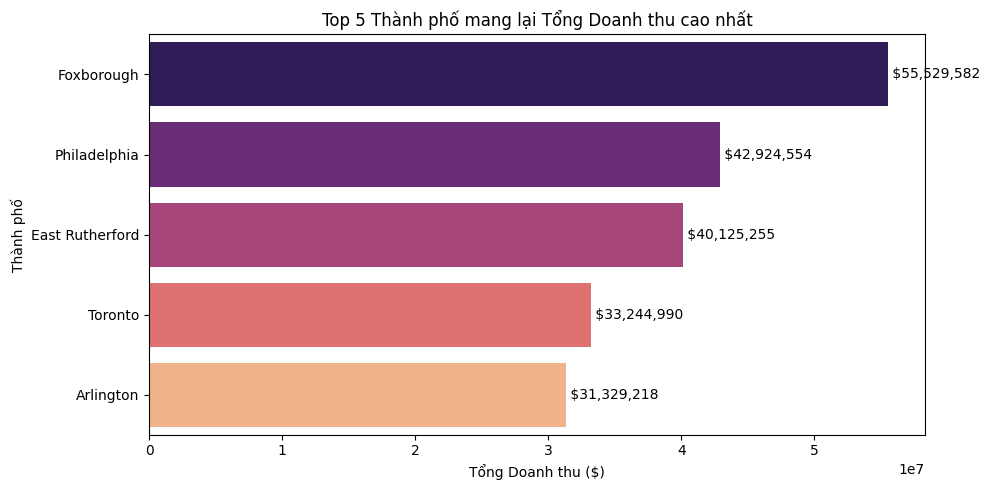

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Revenue', y='City', data=top5_cities, palette='magma')

plt.title('Top 5 Thành phố mang lại Tổng Doanh thu cao nhất')
plt.xlabel('Tổng Doanh thu ($)')
plt.ylabel('Thành phố')
for index, value in enumerate(top5_cities['Revenue']):
    plt.text(value, index, f' ${value:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Nhận xét Top 5 Thành phố Doanh thu cao nhất

| Hạng | Thành phố | Tổng Doanh thu |
|---|---|---|
| 1 | **Foxborough** | $55,529,577 |
| 2 | **Philadelphia** | $42,924,551 |
| 3 | **East Rutherford** | $40,125,259 |
| 4 | **Toronto** | $33,244,991 |
| 5 | **Arlington** | $31,329,218 |

- **Foxborough** dẫn đầu nhờ Gillette Stadium — venue xuất hiện nhiều nhất xuyên suốt các tour.
- Toàn bộ top 5 đều là các thành phố lớn Bắc Mỹ với stadium sức chứa khổng lồ -> các thị trường quan trọng đối với hoạt động concert.
- Phân phối doanh thu theo địa lý **rất tập trung** — một số ít thành phố tạo ra phần lớn tổng doanh thu.

> 💡 `City` là feature địa lý có giá trị nhưng cardinality cao — nên dùng target encoding hoặc nhóm theo region thay vì one-hot encoding.

#### Tour vs Ticket Sold

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_17596\957558070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tour', y='Tickets sold', data=df, palette='Set2')


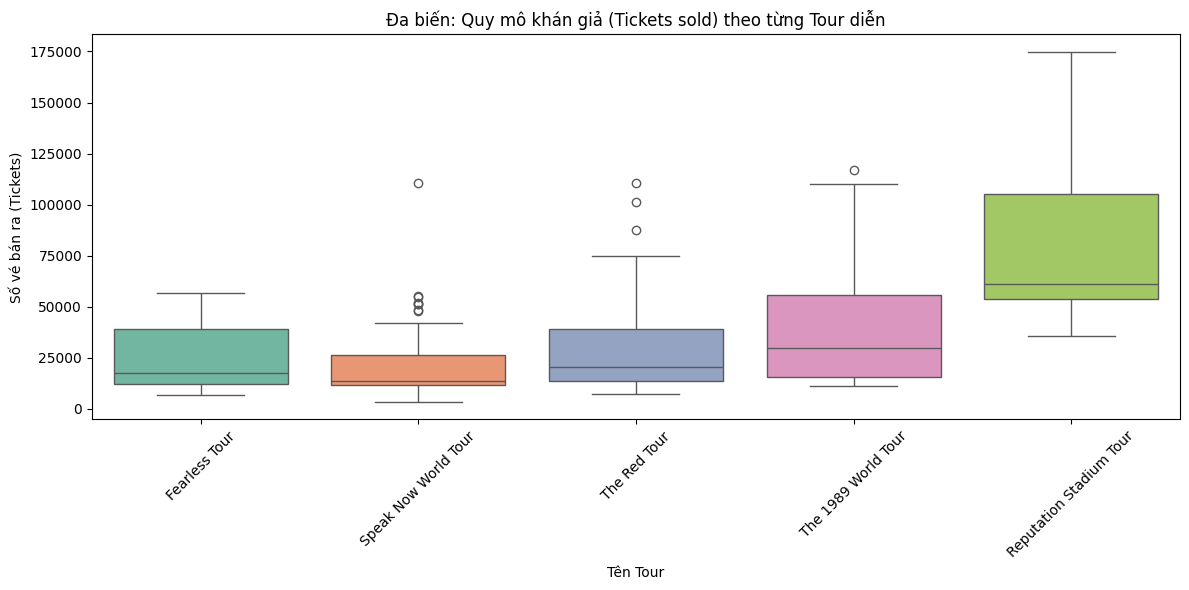

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tour', y='Tickets sold', data=df, palette='Set2')
plt.title('Đa biến: Quy mô khán giả (Tickets sold) theo từng Tour diễn')
plt.xlabel('Tên Tour')
plt.ylabel('Số vé bán ra (Tickets)')
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

### Nhận xét Quy mô Khán giả (Tickets Sold) theo Tour

| Tour | Trung bình | Trung vị | Max |
|---|---|---|---|
| Fearless Tour | 23,816 | 17,793 | 56,868 |
| Speak Now World Tour | 20,063 | 13,734 | 110,800 |
| The Red Tour | 28,723 | 20,711 | 110,712 |
| The 1989 World Tour | 42,846 | 29,688 | 116,849 |
| **Reputation Stadium Tour** | **80,248** | **61,027** | **174,764** |

- Mỗi tour có 'đặc trưng quy mô' riêng biệt rõ ràng — phản ánh sự phân tầng theo loại venue (indoor arena vs outdoor stadium).
- Reputation Stadium Tour có median vé gấp **~3.4 lần** Fearless Tour — bước nhảy lớn nhất trong lịch sử career.
- Độ phân tán rộng ở một số tour cho thấy ngay trong cùng một tour, các show diễn vẫn có thể có quy mô rất khác nhau. Một số show xuất hiện như outliers vì bán được nhiều vé hơn đáng kể so với mặt bằng chung của tour đó.
- Speak Now và Fearless có IQR hẹp, ổn định. Red Tour và 1989 bắt đầu mix giữa indoor và outdoor venues nên IQR rộng hơn.
- Các outliers phía trên (Speak Now, Red Tour) xác nhận những đêm đặc biệt tại stadium — sẽ được phân tích ở phần tiếp theo.

=> Điều này cho thấy sự phát triển của tour có liên quan chặt chẽ đến sự mở rộng tệp khán giả. Khi fanbase của nghệ sĩ tăng lên, tour có thể chuyển từ các venue nhỏ hơn sang các sân vận động lớn hơn, từ đó làm tăng số vé bán ra và cải thiện hiệu quả doanh thu.

## 5. Phân tích Outliers

### Tour vs Ticket Sold

In [16]:
def find_outliers_iqr(data, group_col, target_col):
    outliers = []
    # Duyệt qua từng Tour
    for group in data[group_col].unique():
        subset = data[data[group_col] == group][target_col]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Lấy ra những show nằm ngoài khoảng (lower_bound, upper_bound)
        outlier_rows = data[(data[group_col] == group) & ((data[target_col] < lower_bound) | (data[target_col] > upper_bound))]
        outliers.append(outlier_rows)
    
    return pd.concat(outliers)

# 2. Gọi hàm để lấy danh sách Outliers của Tickets sold theo từng Tour
outliers_df = find_outliers_iqr(df, 'Tour', 'Tickets sold')

# 3. In ra kết quả để kiểm tra
print(f"Tổng cộng có {len(outliers_df)} show diễn là Outliers về lượng vé:")
display(outliers_df[['Tour', 'City', 'Venue', 'Tickets sold']].sort_values(by='Tickets sold', ascending=False))

Tổng cộng có 12 show diễn là Outliers về lượng vé:


,Tour,City,Venue,Tickets sold
264,The 1989 World Tour,Foxborough,Gillette Stadium,116849.0
127,Speak Now World Tour,Foxborough,Gillette Stadium,110800.0
210,The Red Tour,Foxborough,Gillette Stadium,110712.0
209,The Red Tour,Philadelphia,Lincoln Financial Field,101277.0
203,The Red Tour,Toronto,Rogers Centre,87627.0
156,Speak Now World Tour,Arlington,Cowboys Stadium,55451.0
141,Speak Now World Tour,Los Angeles,Staples Center,54900.0
124,Speak Now World Tour,Pittsburgh,Heinz Field,52009.0
132,Speak Now World Tour,Newark,Prudential Center,51487.0
137,Speak Now World Tour,Philadelphia,Lincoln Financial Field,51395.0


### Nhận xét Outliers — Tickets Sold theo Tour

Kết quả phân tích cho thấy có tổng cộng **12 show** có lượng vé bất thường so với mặt bằng chung của từng tour:

- **Gillette Stadium (Foxborough)** xuất hiện nhiều nhất — venue sức chứa đặc biệt lớn, được dùng xuyên suốt nhiều tour.
- Phần lớn outliers thuộc **Speak Now World Tour** (7/12 show) — tour này có biến động quy mô lớn nhất, từ venue nhỏ đến sân vận động NFL.
- Các show outlier tập trung ở **Foxborough, Philadelphia, Toronto, Arlington** — các thành phố có sân vận động đa năng ngoài trời.

> 💡 Đây là dữ liệu **thực tế có giá trị thông tin cao** — không nên xóa. Có thể tạo feature `is_stadium_show` để model học được đặc trưng này.

#### Ticket Sold vs Revenue

In [17]:
# 1. Tính toán giá vé trung bình (Price per ticket) để tìm điểm vô lý
df['Price_per_Ticket'] = df['Revenue'] / df['Tickets sold']

# 2. Tìm ngưỡng outliers. 
# Thông thường, các show có giá vé trung bình quá cao hoặc quá thấp so với mặt bằng chung là outliers.
price_mean = df['Price_per_Ticket'].mean()
price_std = df['Price_per_Ticket'].std()

# Lấy các show có giá vé lệch hơn 2 lần độ lệch chuẩn (Z-score > 2)
scatter_outliers = df[(df['Price_per_Ticket'] > price_mean + 2*price_std) | 
                      (df['Price_per_Ticket'] < price_mean - 2*price_std)]

print(f"Phát hiện {len(scatter_outliers)} điểm dị biệt trên Scatterplot:")
display(scatter_outliers[['Tour', 'City', 'Revenue', 'Tickets sold', 'Price_per_Ticket']].sort_values(by='Price_per_Ticket', ascending=False))

Phát hiện 13 điểm dị biệt trên Scatterplot:


,Tour,City,Revenue,Tickets sold,Price_per_Ticket
237,The Red Tour,Jakarta,1481473.0,8130.0,182.223001
291,The 1989 World Tour,Singapore,3217569.0,17726.0,181.516924
325,Reputation Stadium Tour,Houston,9350275.0,53800.0,173.796933
318,Reputation Stadium Tour,Nashville,9007179.0,56112.0,160.521439
292,The 1989 World Tour,Shanghai,5917348.0,37758.0,156.717729
315,Reputation Stadium Tour,Atlanta,18089415.0,116746.0,154.946765
300,Reputation Stadium Tour,Seattle,8672219.0,56021.0,154.803002
238,The Red Tour,Pasay,1511662.0,9775.0,154.645729
239,The Red Tour,Singapore,2524080.0,16344.0,154.434655
332,Reputation Stadium Tour,Tokyo,14859847.0,100109.0,148.436674


### Nhận xét Outliers — Price per Ticket (Giá vé trung bình)

Kết quả phân tích cho thấy có tổng cộng **13 show** có giá vé trung bình bất thường (Z-score > 2σ so với mean $86.7, std $27.4):

- Giá vé trung bình thông thường dao động **$60–$114**. Các show outlier có giá **$148–$182/vé**.
- **Jakarta ($182) và Pasay/Philippines ($154)** thuộc The Red Tour đứng đầu — giá vé premium ở thị trường Đông Nam Á khi Taylor Swift lần đầu biểu diễn tại đây (cung ít, cầu cao).
- **Singapore** xuất hiện ở cả Red Tour và 1989 World Tour ($154–$181) — thị trường này luôn có giá vé cao hơn mặt bằng chung.
- **Reputation Stadium Tour** tại Mỹ (Houston, Nashville, Atlanta) cũng lọt danh sách — chiến lược định giá premium của tour này.

> 💡 **Insight:** Giá vé cao ở châu Á không phải dữ liệu lỗi mà là thực tế thị trường. Nên giữ lại và cân nhắc bổ sung feature `is_asia_show` hoặc `Country_region`.

#### Tour vs Revenue

In [18]:
# 1. Định nghĩa hàm tìm outliers theo phương pháp IQR cho từng nhóm
def get_outliers_by_tour(data, group_col, target_col):
    all_outliers = []
    
    # Chạy vòng lặp qua từng Tour để tìm outliers riêng cho tour đó
    for tour_name in data[group_col].unique():
        subset = data[data[group_col] == tour_name][target_col]
        
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Lọc ra các dòng nằm ngoài khoảng an toàn
        outlier_rows = data[(data[group_col] == tour_name) & ((data[target_col] < lower_bound) | (data[target_col] > upper_bound))]
        all_outliers.append(outlier_rows)
        
    return pd.concat(all_outliers)

# 2. Áp dụng cho cột Revenue và Tour
revenue_outliers = get_outliers_by_tour(df, 'Tour', 'Revenue')

# 3. Hiển thị kết quả
print(f"Tìm thấy {len(revenue_outliers)} show diễn là outliers về doanh thu:")
display(revenue_outliers[['Tour', 'City', 'Venue', 'Revenue']].sort_values(by='Revenue', ascending=False))

Tìm thấy 14 show diễn là outliers về doanh thu:


,Tour,City,Venue,Revenue
311,Reputation Stadium Tour,East Rutherford,MetLife Stadium,22031386.0
312,Reputation Stadium Tour,Foxborough,Gillette Stadium,21779846.0
261,The 1989 World Tour,East Rutherford,MetLife Stadium,13423858.0
268,The 1989 World Tour,Santa Clara,Levi's Stadium,13031146.0
264,The 1989 World Tour,Foxborough,Gillette Stadium,12533166.0
210,The Red Tour,Foxborough,Gillette Stadium,9464063.0
209,The Red Tour,Philadelphia,Lincoln Financial Field,8822335.0
127,Speak Now World Tour,Foxborough,Gillette Stadium,8026350.0
156,Speak Now World Tour,Arlington,Cowboys Stadium,4337062.0
137,Speak Now World Tour,Philadelphia,Lincoln Financial Field,4268678.0


### Nhận xét Outliers — Revenue theo Tour

Kết quả phân tích cho thấy có tổng cộng **14 show** có doanh thu outlier trong từng tour:

- **Reputation Stadium Tour:** MetLife Stadium (East Rutherford) **$22.03M** và Gillette Stadium (Foxborough) **$21.78M** — 2 show doanh thu cao nhất toàn bộ dataset.
- **The 1989 World Tour:** MetLife Stadium $13.42M và Levi's Stadium $13.03M — các venue NFL/MLS siêu lớn bờ Đông và Tây nước Mỹ.
- **The Red Tour và Speak Now:** Outliers đều tập trung ở Gillette Stadium và Lincoln Financial Field (Philadelphia) — **Foxborough và Philadelphia là hai 'cash cow' nhất quán xuyên suốt mọi tour**.
- **Melbourne (Speak Now)** là outlier duy nhất ngoài Mỹ/Canada trong nhóm này — thị trường Úc có sức hút đặc biệt.

> 💡 **Pattern rõ ràng:** Outliers doanh thu không ngẫu nhiên — chúng đến từ các venue lớn tại các thành phố cụ thể. Tổ hợp **Venue + City** là feature rất có giá trị cho modeling.

#### Revenue

In [19]:
# 1. Tính toán các thông số IQR cho toàn bộ cột Revenue
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

# 2. Xác định ngưỡng trên (Thường outliers doanh thu chỉ nằm ở phía trên)
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# 3. Lọc ra các show "siêu giàu"
total_revenue_outliers = df[(df['Revenue'] > upper_bound) | (df['Revenue'] < lower_bound)]

print(f"Ngưỡng doanh thu bình thường tối đa là: ${upper_bound:,.0f}")
print(f"Tổng số show diễn vượt ngưỡng (chấm đen trên biểu đồ): {len(total_revenue_outliers)}")

# Hiển thị danh sách 10 show khủng nhất
display(total_revenue_outliers[['Tour', 'City', 'Revenue']].sort_values(by='Revenue', ascending=False).head(10))

Ngưỡng doanh thu bình thường tối đa là: $8,385,473
Tổng số show diễn vượt ngưỡng (chấm đen trên biểu đồ): 29


,Tour,City,Revenue
311,Reputation Stadium Tour,East Rutherford,22031386.0
312,Reputation Stadium Tour,Foxborough,21779846.0
315,Reputation Stadium Tour,Atlanta,18089415.0
299,Reputation Stadium Tour,Pasadena,16251980.0
326,Reputation Stadium Tour,Arlington,15006157.0
332,Reputation Stadium Tour,Tokyo,14859847.0
302,Reputation Stadium Tour,Chicago,14576697.0
298,Reputation Stadium Tour,Santa Clara,14006963.0
261,The 1989 World Tour,East Rutherford,13423858.0
268,The 1989 World Tour,Santa Clara,13031146.0


### Nhận xét Outliers — Revenue toàn bộ dataset

- **Ngưỡng Revenue bình thường** (IQR global): tối đa **$8,385,473**. Có **29 show** vượt ngưỡng này.
- Phần lớn trong 29 outliers thuộc **Reputation Stadium Tour** và **The 1989 World Tour** — hai tour lớn nhất hoàn toàn thống trị nhóm này.
- Top 10 show cao nhất đều tại các **sân vận động NFL/MLB** ở các thành phố lớn nhất nước Mỹ.

**Tổng kết phân tích Outliers:**

| Phân tích | Phương pháp | Số outliers | Kết quả chính |
|---|---|---|---|
| Tickets Sold theo Tour | IQR per group | 12 | Show stadium trong các tour nhỏ |
| Price per Ticket | Z-score ±2σ | 13 | Châu Á + Reputation Tour premium |
| Revenue theo Tour | IQR per group | 14 | Foxborough, Philadelphia, East Rutherford |
| Revenue toàn cục | IQR global | 29 | Chủ yếu Reputation + 1989 Tour |

> ✅ **Quyết định xử lý:** **Giữ nguyên tất cả outliers** — đây là dữ liệu thực tế phản ánh sự kiện có thật. Random Forest xử lý outliers tốt. Có thể bổ sung `is_stadium_show` hoặc `is_asia_show` để model nhận diện các nhóm này tốt hơn.

## 6. Kết luận EDA & Định hướng tiếp theo

### Những phát hiện chính

1. **Revenue phân phối lệch phải mạnh** (skewness = 2.32) — bị kéo bởi các show Reputation Stadium Tour. Cần log-transform nếu dùng model tuyến tính.
2. **`Tickets sold` là biến tương quan mạnh nhất với Revenue** (r = 0.96) — feature quan trọng số 1. `Tickets available` gần như trùng thông tin nên có thể bỏ bớt.
3. **Tour là yếu tố phân nhóm mạnh nhất** — doanh thu TB/show tăng từ $1.5M (Speak Now) lên $9.6M (Reputation), phản ánh bước nhảy về quy mô sản xuất.
4. **Hầu hết show bán hết vé** (fill rate ≈ 1.0) — Tickets remaining không có giá trị phân biệt trong dataset này.
5. **Phân phối địa lý tập trung** — Foxborough, Philadelphia, East Rutherford là top 3 thành phố doanh thu cao nhất xuyên suốt mọi tour.
6. **Giá vé trung bình** ($87/vé) chênh lệch lớn theo khu vực — châu Á và Reputation Tour có giá premium đáng kể.